# SmartSplit Nepal - Machine Learning

**Utsuk Kharel** | BSc (Hons) Computer Science with Artificial Intelligence, Sunway College Kathmandu

This notebook builds the two machine-learning models used by the SmartSplit Nepal web application.

| Model | Task | Where it is used in the app |
|---|---|---|
| Expense category classifier | Multi-class text classification (9 categories) | The Quick Split wizard suggests a category as the user types the description |
| Monthly spending forecaster | Regression on a monthly time series | A group's Overview tab shows next month's predicted spending, with the reasons |

## About the dataset

There is no public dataset of individual Nepali household transactions, so the dataset was
**synthesised from published Nepali price data**. Every price range in `build_dataset.py` is taken
from `data/price_reference.csv`, which records the source of each figure: Nepal Oil Corporation fuel
and LPG rates, NEA domestic tariff slabs, Kalimati wholesale vegetable prices, NTC/Ncell and ISP
package prices, published bus, cinema, hotel and paragliding rates, room-rent listings and published
college fee guides, and festival prices such as khasi meat and Tihar marigold garlands.

The year follows the **real Nepali festival calendar** in `data/festival_calendar.csv`: every
festival and event that noticeably changes spending, on its actual date for each year from 2023 to
2027, with a source for each date. That covers Dashain, Tihar, Chhath, Teej, Janai Purnima, Krishna
Janmashtami, Holi, Maha Shivaratri, Nepali New Year, Buddha Jayanti, Maghe Sankranti, Sonam, Gyalpo
and Tamu Lhosar, Eid al-Fitr and Eid al-Adha, Christmas, New Year's Eve, Mother's and Father's Day,
Shree Panchami, Gai Jatra, Indra Jatra, Yomari Punhi and the three wedding seasons. Households
celebrate according to a profile, and each has its own birthdays. Recurring bills, monsoon vegetable
prices, semester fees and winter electricity use are modelled as well.

The dataset is therefore realistic in its prices and its seasonality, but it is not collected from
real users, and no conclusion in this notebook should be read as a measurement of real household
behaviour. Reproducing it is a single command:

```bash
python ml/build_dataset.py
```

In [1]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path("ml")
DATA = BASE / "data"
MODELS = BASE / "models"
MODELS.mkdir(exist_ok=True, parents=True)

import sys
sys.path.insert(0, str(BASE.resolve()))
from festivals import festival_details_by_month, load_calendar, national_intensity_by_month

expenses = pd.read_csv(DATA / "expenses.csv", parse_dates=["date"], keep_default_na=False)
calendar = load_calendar(DATA / "festival_calendar.csv")
households = pd.read_csv(DATA / "households.csv", keep_default_na=False)
monthly = pd.read_csv(DATA / "monthly_spending.csv")
prices = pd.read_csv(DATA / "price_reference.csv")

print("expenses        ", expenses.shape)
print("monthly         ", monthly.shape)
print("price reference ", prices.shape)
print("festival rows   ", len(calendar))
expenses.head()

expenses         (12822, 8)
monthly          (540, 9)
price reference  (51, 9)
festival rows    118


,date,description,amount_npr,category,persona,household,group_type,festival
0,2023-10-01,Buff momo Jhamsikhel Saturday,100,food,family,family_2,family,
1,2023-10-01,Cafe bill Baneshwor Saturday,700,food,family,family_2,family,
2,2023-10-01,Medicine from phrmacy for Sujan,1620,other,family,family_2,family,
3,2023-10-01,Cab to airport with luggage - with Bikash,1100,transport,student_home,student_home_2,college,
4,2023-10-01,BUS TICKET AND KHAJA ON THE WAY,590,transport,student_home,student_home_3,college,


## 1. Exploratory data analysis

In [2]:
print("Date range :", expenses.date.min().date(), "to", expenses.date.max().date())
print("Households :", expenses.household.nunique())
print("Categories :", expenses.category.nunique())
print("Total value: Rs.", f"{expenses.amount_npr.sum():,}")
expenses.describe(include="all").T[["count", "unique", "top", "freq", "mean", "min", "max"]]

Date range : 2023-10-01 to 2026-09-30
Households : 15
Categories : 9
Total value: Rs. 41,011,840


,count,unique,top,freq,mean,min,max
date,12822,NaN,NaN,NaN,2025-03-27 10:06:13.982218,2023-10-01 00:00:00,2026-09-30 00:00:00
description,12822,5342,Wifi bill,111,NaN,NaN,NaN
amount_npr,12822.0,NaN,NaN,NaN,3198.552488,15.0,154650.0
category,12822,9,food,4324,NaN,NaN,NaN
persona,12822,5,family,3540,NaN,NaN,NaN
household,12822,15,family_2,1363,NaN,NaN,NaN
group_type,12822,4,roommates,5572,NaN,NaN,NaN
festival,12822,30,,11004,NaN,NaN,NaN


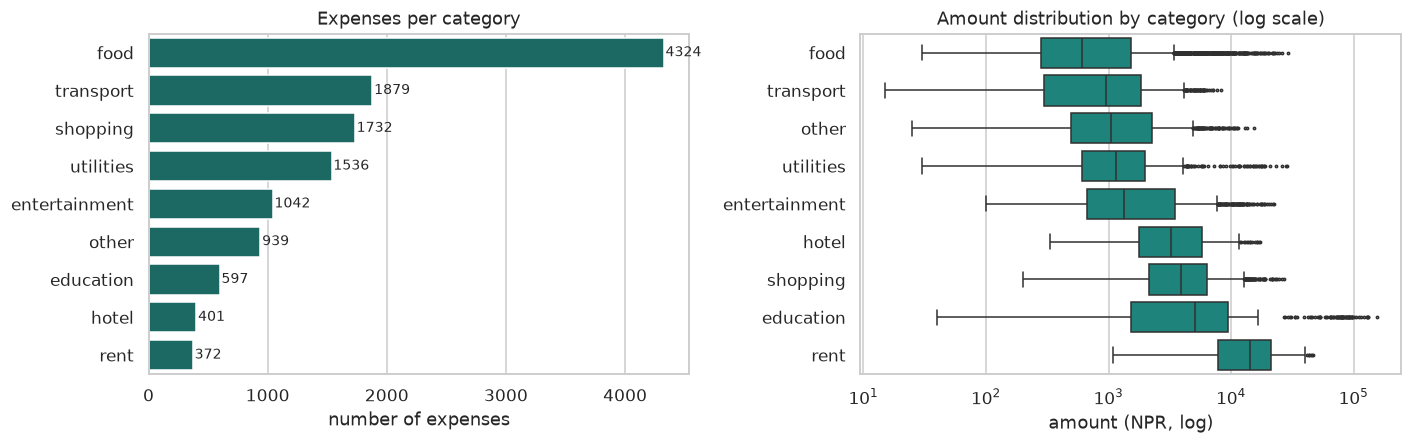

In [3]:
counts = expenses.category.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.barplot(x=counts.values, y=counts.index, ax=axes[0], color="#0f766e")
axes[0].set(title="Expenses per category", xlabel="number of expenses", ylabel="")
for i, v in enumerate(counts.values):
    axes[0].text(v + 15, i, str(v), va="center", fontsize=9)

order = expenses.groupby("category").amount_npr.median().sort_values().index
sns.boxplot(data=expenses, x="amount_npr", y="category", order=order, ax=axes[1],
            color="#0d9488", fliersize=1.5)
axes[1].set(xscale="log", title="Amount distribution by category (log scale)",
            xlabel="amount (NPR, log)", ylabel="")
plt.tight_layout()
plt.show()

The class distribution is imbalanced in the way a real expense log is: food is the most frequent
category by a wide margin, while hotel and rent appear rarely but carry large amounts. Because of
this imbalance, accuracy alone would be a misleading score, so macro-averaged F1 is used as the
selection metric throughout, and the per-class report is inspected before any model is accepted.

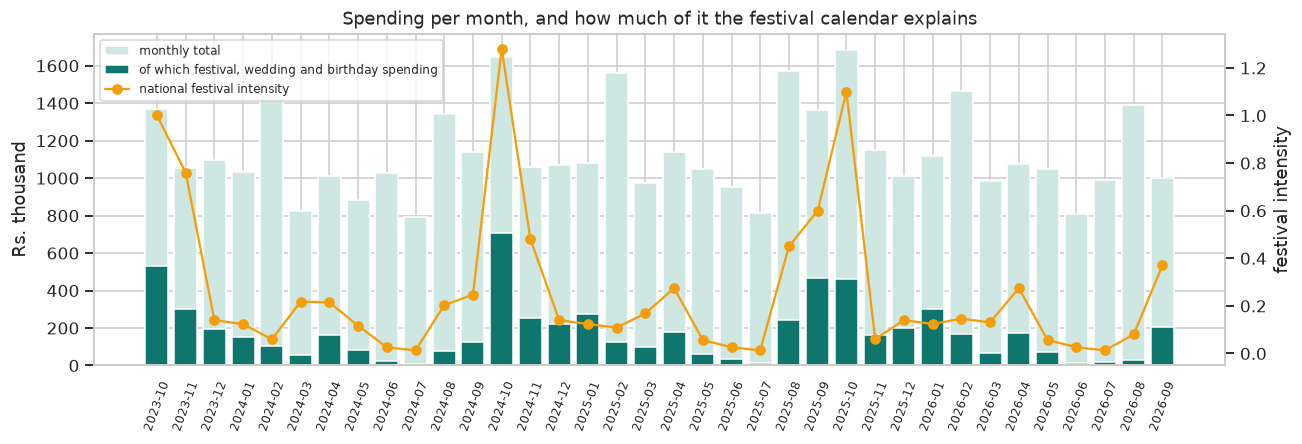

Most festive months:
  month  intensity  total_npr
2024-10       1.28    1646045
2025-10       1.10    1686165
2023-10       1.00    1369235
2023-11       0.76    1051875


In [4]:
series = (monthly.groupby("month", as_index=False)
          .agg(total_npr=("total_npr", "sum"), festival_npr=("festival_npr", "sum"),
               intensity=("festival_intensity", "first")))

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.bar(series.month, series.total_npr / 1000, color="#cfe7e3", label="monthly total")
ax.bar(series.month, series.festival_npr / 1000, color="#0f766e", label="of which festival, wedding and birthday spending")
ax2 = ax.twinx()
ax2.plot(series.month, series.intensity, color="#f59e0b", marker="o", label="national festival intensity")
ax2.set_ylabel("festival intensity")
ax2.grid(False)
ax.set(title="Spending per month, and how much of it the festival calendar explains", ylabel="Rs. thousand")
ax.tick_params(axis="x", rotation=70, labelsize=8)
lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
ax.legend(lines, [l.get_label() for l in lines], loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

top = series.sort_values("intensity", ascending=False).head(4)[["month", "intensity", "total_npr"]]
print("Most festive months:")
print(top.to_string(index=False))

Dashain moves with the lunar calendar: it began on 22 September in 2025 but on 11 October in 2026.
The chart shows the consequence directly. In 2025 the festival spike is split between September and
October, which a fixed "October and November" rule would have placed in the wrong month.

In [5]:
in_window = [f for f in calendar if f.end >= expenses.date.min().date() and f.start <= expenses.date.max().date()]
calendar_table = pd.DataFrame([
    {"festival": f.name, "starts": f.start, "main day": f.peak, "scale": f.scale,
     "kept by": ", ".join(sorted(f.celebrated_by))}
    for f in in_window if not f.key.startswith("wedding")
])
print(len(in_window), "festival and wedding-season entries fall inside the data window")
calendar_table[calendar_table["main day"].astype(str).str.startswith("2025")]

84 festival and wedding-season entries fall inside the data window


,festival,starts,main day,scale,kept by
32,Maghe Sankranti / Maghi,2025-01-13,2025-01-14,medium,all
33,Sonam Lhosar,2025-01-27,2025-01-30,medium,tamang
34,Shree Panchami (Saraswati Puja),2025-02-03,2025-02-03,minor,students
35,Valentine's Day,2025-02-14,2025-02-14,minor,youth
36,Gyalpo Lhosar,2025-02-25,2025-02-28,medium,sherpa
37,Maha Shivaratri,2025-02-26,2025-02-26,minor,hindu
38,Holi (Fagu Purnima),2025-03-11,2025-03-13,medium,all
39,Eid al-Fitr,2025-03-27,2025-03-31,medium,muslim
40,Nepali New Year,2025-04-13,2025-04-14,medium,all
41,Mata Tirtha Aunsi (Mother's Day),2025-04-27,2025-04-27,minor,all


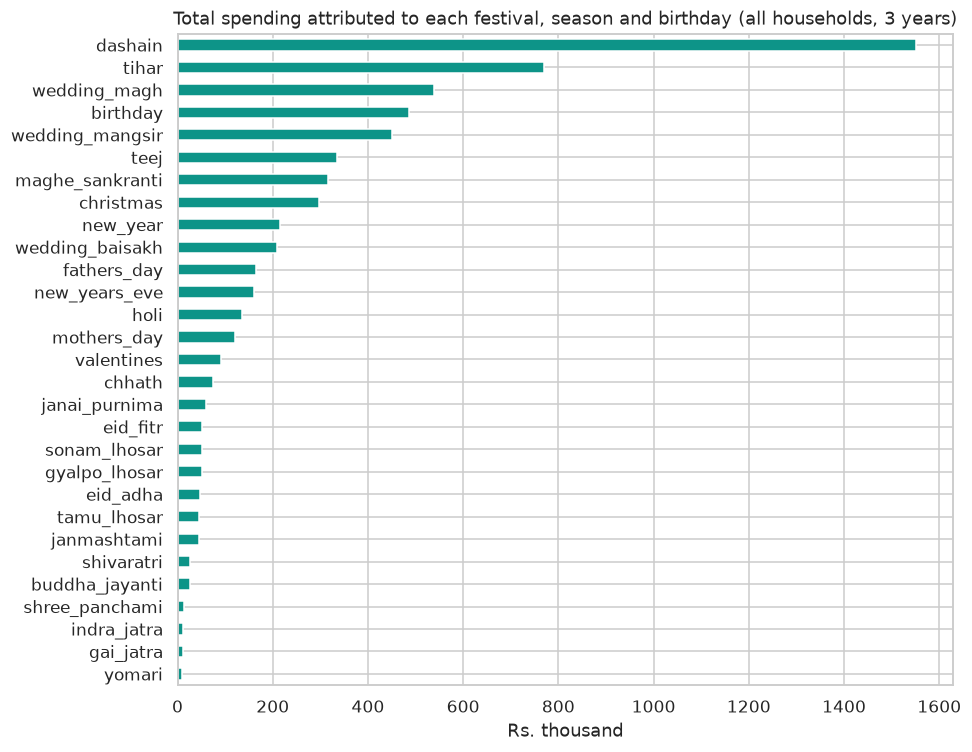

14.2% of expenses and 15.5% of all money spent are festival, wedding or birthday purchases


In [6]:
by_festival = (expenses[expenses.festival != ""]
               .groupby("festival").amount_npr.agg(["sum", "count"])
               .sort_values("sum", ascending=True))

by_festival["sum"].div(1000).plot(kind="barh", figsize=(9, 7), color="#0d9488")
plt.title("Total spending attributed to each festival, season and birthday (all households, 3 years)")
plt.xlabel("Rs. thousand")
plt.ylabel("")
plt.tight_layout()
plt.show()
print(f"{expenses.festival.ne('').mean():.1%} of expenses and "
      f"{expenses.loc[expenses.festival.ne(''), 'amount_npr'].sum() / expenses.amount_npr.sum():.1%} "
      "of all money spent are festival, wedding or birthday purchases")

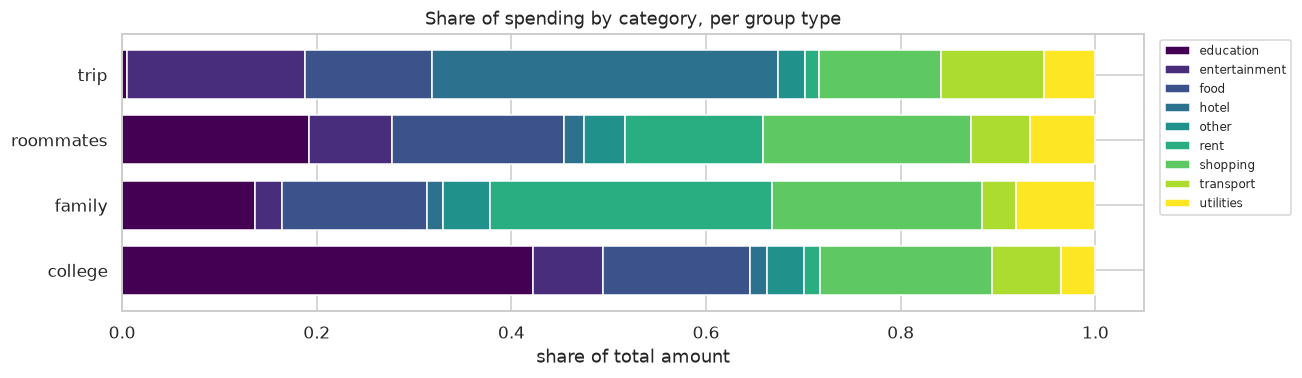

category,education,entertainment,food,hotel,other,rent,shopping,transport,utilities
group_type,,,,,,,,,
college,42.3,7.2,15.1,1.7,3.8,1.7,17.6,7.1,3.5
family,13.7,2.7,15.0,1.6,4.8,29.0,21.6,3.5,8.1
roommates,19.2,8.6,17.6,2.1,4.2,14.2,21.4,6.0,6.7
trip,0.5,18.3,13.1,35.5,2.8,1.4,12.6,10.5,5.3


In [7]:
share = (expenses.pivot_table(index="group_type", columns="category",
                              values="amount_npr", aggfunc="sum", fill_value=0))
share = share.div(share.sum(axis=1), axis=0)

share.plot(kind="barh", stacked=True, figsize=(12, 3.6), colormap="viridis", width=0.75)
plt.title("Share of spending by category, per group type")
plt.xlabel("share of total amount")
plt.ylabel("")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()
(share * 100).round(1)

Spending composition differs clearly by group type: trip groups put most of their money into hotel,
transport and entertainment, while family and roommate groups are dominated by food, rent and
utilities. This matters for the app, because category prediction and forecasting are both applied
inside a specific group.

## 2. Text preprocessing

In [8]:
def clean(text: str) -> str:
    """Lower-case, strip punctuation and digits, collapse whitespace.

    Digits are removed deliberately: '5 litre' and '3 months' carry no information about the
    category, and keeping them would inflate the vocabulary with one-off tokens.
    """
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


expenses["clean"] = expenses.description.map(clean)
expenses[["description", "clean", "category"]].sample(8, random_state=RANDOM_STATE)

,description,clean,category
7386,College bus fee Ring Road,college bus fee ring road,transport
9517,Khaja half plate,khaja half plate,food
3037,Netflix subscription split for 4 people,netflix subscription split for people,entertainment
3026,HOMESTAY SAURAHA WEEKEND RATE,homestay sauraha weekend rate,hotel
2692,trip to matatirtha morning,trip to matatirtha morning,transport
10206,InDrive to Jhamsikhel - return,indrive to jhamsikhel return,transport
11846,Bedsheet and pillow,bedsheet and pillow,shopping
3404,Cable car ticket Ring Road,cable car ticket ring road,transport


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vocab_check = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
vocab_check.fit(expenses["clean"])
print("Vocabulary size (word 1-2 grams, min_df=2):", len(vocab_check.vocabulary_))
print("Unique descriptions                      :", expenses.description.nunique())
print("Mean words per description               :", expenses["clean"].str.split().str.len().mean().round(2))

top_terms = {}
for category in sorted(expenses.category.unique()):
    subset = expenses.loc[expenses.category == category, "clean"]
    tfidf = TfidfVectorizer(stop_words="english", max_features=2000)
    matrix = tfidf.fit_transform(subset)
    scores = np.asarray(matrix.mean(axis=0)).ravel()
    names = np.array(tfidf.get_feature_names_out())
    top_terms[category] = ", ".join(names[scores.argsort()[::-1][:6]])

pd.Series(top_terms, name="most characteristic terms").to_frame()

Vocabulary size (word 1-2 grams, min_df=2): 2521
Unique descriptions                      : 5342
Mean words per description               : 3.75


,most characteristic terms
education,"fee, monthly, tuition, school, sem, th"
entertainment,"ticket, booking, movie, entry, pool, evening"
food,"khaja, momo, chiya, lunch, chicken, plate"
hotel,"hotel, breakfast, booking, advance, check, lak..."
other,"emergency, cash, urgent, laundry, visit, misce..."
rent,"rent, room, flat, paid, wifi, landlord"
shopping,"gift, shopping, dashain, wedding, headphones, new"
transport,"bus, petrol, taxi, airport, college, ticket"
utilities,"wifi, khanepani, gas, cylinder, electricity, nea"


The characteristic terms are what we would expect a Nepali user to type, and several of them are
shared between categories: *hotel* appears in both hotel bills and restaurant meals, *shopping*
appears in shopping and in utility purchases such as a gas cylinder, and *chiya* appears in food
entries logged at a college canteen. Those overlaps are the ones the confusion matrix below should
show.

## 3. Category classifier: model selection

In [10]:
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_val_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

X = expenses["clean"]
y = expenses["category"]
groups = expenses["clean"]          # identical wording must not straddle the split

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

print("train:", len(X_train), " test:", len(X_test))
print("descriptions shared between train and test:",
      len(set(X_train) & set(X_test)))

def make_features() -> FeatureUnion:
    """Fresh, unfitted feature union. A new instance per pipeline: scikit-learn Pipelines do
    not clone their steps, so sharing one union between pipelines would refit it in place and
    silently invalidate the model fitted earlier."""
    return FeatureUnion([
        ("word", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3, sublinear_tf=True)),
    ])

candidates = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.3),
    "Logistic Regression": LogisticRegression(max_iter=2000, C=6, class_weight="balanced"),
    "Linear SVM": LinearSVC(C=1.0, class_weight="balanced"),
}

cv = GroupKFold(n_splits=5)
rows = []
for name, model in candidates.items():
    pipe = Pipeline([("features", make_features()), ("clf", model)])
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv, groups=groups_train,
                         scoring="f1_macro", n_jobs=-1)
    acc = cross_val_score(pipe, X_train, y_train, cv=cv, groups=groups_train,
                          scoring="accuracy", n_jobs=-1)
    rows.append({"model": name, "cv macro F1": f1.mean(), "F1 std": f1.std(),
                 "cv accuracy": acc.mean()})

results = pd.DataFrame(rows).sort_values("cv macro F1", ascending=False).reset_index(drop=True)
results.round(4)

train: 10108  test: 2714
descriptions shared between train and test: 0


,model,cv macro F1,F1 std,cv accuracy
0,Logistic Regression,0.9595,0.0247,0.9627
1,Linear SVM,0.9579,0.0247,0.9609
2,Multinomial Naive Bayes,0.9535,0.0169,0.9619


**Why the split is grouped.** Many people describe the same expense in exactly the same words
("Mobile recharge", "Bus"), so a plain random split would put identical text in both the training
and the test set. The model would then be scored partly on sentences it had memorised, and accuracy
would come out near 100% - a leakage artefact, not a result. `GroupShuffleSplit` and `GroupKFold`
group the rows by their cleaned text, so every wording appears on only one side of the split. The
numbers below are therefore the model's performance on descriptions it has genuinely never seen.

All three candidates are trained on exactly the same features: a union of word 1-2 grams and
character 3-5 grams. The character n-grams matter here because users make typos and mix Romanised
Nepali spellings (*khaja*, *khaaja*, *tarkari*), which a purely word-based model would treat as
unrelated tokens.

In [11]:
best_name = results.iloc[0]["model"]
print("Best by cross-validated macro F1:", best_name)

def build_pipeline(name: str) -> Pipeline:
    """Pipeline for one candidate. LinearSVC has no predict_proba, so it is wrapped in
    CalibratedClassifierCV - the app shows a confidence next to every suggestion."""
    from sklearn.base import clone
    estimator = clone(candidates[name])
    if isinstance(estimator, LinearSVC):
        estimator = CalibratedClassifierCV(estimator, cv=3)
    return Pipeline([("features", make_features()), ("clf", estimator)])


model = build_pipeline(best_name)
model.fit(X_train, y_train)
print("fitted")

Best by cross-validated macro F1: Logistic Regression


fitted


## 4. Category classifier: evaluation

In [12]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, ConfusionMatrixDisplay)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Test accuracy : {accuracy:.4f}")
print(f"Test macro F1 : {macro_f1:.4f}\n")
print(classification_report(y_test, y_pred, digits=3))

Test accuracy : 0.9702
Test macro F1 : 0.9561

               precision    recall  f1-score   support

    education      0.993     1.000     0.996       135
entertainment      0.956     1.000     0.978       283
         food      1.000     0.950     0.974       999
        hotel      0.846     1.000     0.917        88
        other      1.000     0.944     0.971       161
         rent      0.729     0.987     0.839        79
     shopping      1.000     1.000     1.000       357
    transport      0.932     0.997     0.963       291
    utilities      0.997     0.938     0.966       321

     accuracy                          0.970      2714
    macro avg      0.939     0.980     0.956      2714
 weighted avg      0.975     0.970     0.971      2714



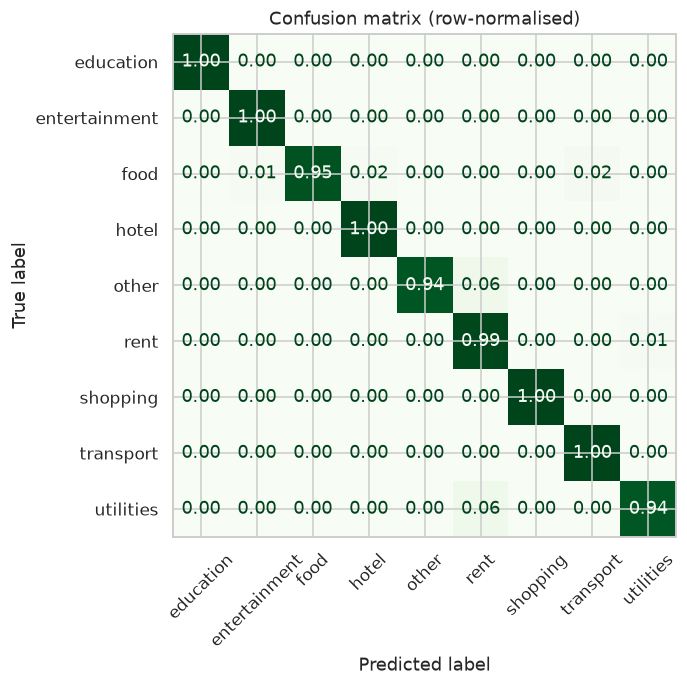

In [13]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(7.5, 6.4))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax, cmap="Greens", colorbar=False, values_format=".2f", xticks_rotation=45)
ax.set_title("Confusion matrix (row-normalised)")
plt.tight_layout()
plt.show()

In [14]:
errors = pd.DataFrame({
    "description": expenses["description"].iloc[test_idx],
    "amount": expenses["amount_npr"].iloc[test_idx],
    "true": y_test,
    "predicted": y_pred,
})
errors = errors[errors.true != errors.predicted]
print(f"{len(errors)} misclassified out of {len(y_test)}\n")
print("Most common confusions:")
print(errors.groupby(["true", "predicted"]).size().sort_values(ascending=False).head(8))
errors.sample(min(10, len(errors)), random_state=RANDOM_STATE)

81 misclassified out of 2714

Most common confusions:
true       predicted    
food       transport        21
utilities  rent             20
food       hotel            15
           entertainment    13
other      rent              9
food       education         1
rent       utilities         1
transport  hotel             1
dtype: int64


,description,amount,true,predicted
4830,bus ticket and khaja on the way,310,food,transport
51,Monthly bill paid - rgent,4750,other,rent
3334,Bus ticket and khaja on the way,480,food,transport
4929,Bus ticket and khaja on the way,520,food,transport
2978,Bus ticket and khaja on the way,1020,food,transport
4539,Bus ticket and khaja on the way,1360,food,transport
1599,Snacks during movie - for 3 people,290,food,entertainment
11098,Monthly bill paid,10800,utilities,rent
899,College cantee chiya,60,food,education
1772,Monthly bill paid,2950,utilities,rent


The errors are concentrated where the text genuinely is ambiguous: a canteen meal logged during a
college trip, a restaurant bill described only as *hotel dinner*, or a gas cylinder written as
*shopping for kitchen gas*. A human reading only the description would make the same mistakes,
which is the point at which more training data stops helping and a different signal is needed.

The application handles this honestly rather than hiding it: the predicted category is offered as a
*suggestion* with its confidence, and the user can ignore it with one click.

### 4.1 Does the amount help?

In [15]:
def bucket(amount: float) -> str:
    """Coarse amount band, appended to the text as an extra token."""
    if amount < 200:
        return "amt_tiny"
    if amount < 1000:
        return "amt_small"
    if amount < 5000:
        return "amt_mid"
    if amount < 20000:
        return "amt_large"
    return "amt_huge"


expenses["clean_amt"] = expenses["clean"] + " " + expenses.amount_npr.map(bucket)

Xa_train = expenses["clean_amt"].iloc[train_idx]
Xa_test = expenses["clean_amt"].iloc[test_idx]

model_amt = build_pipeline(best_name)
model_amt.fit(Xa_train, y_train)
ya_pred = model_amt.predict(Xa_test)

comparison = pd.DataFrame([
    {"variant": "description only", "accuracy": accuracy,
     "macro F1": macro_f1},
    {"variant": "description + amount band", "accuracy": accuracy_score(y_test, ya_pred),
     "macro F1": f1_score(y_test, ya_pred, average="macro")},
])
comparison.round(4)

,variant,accuracy,macro F1
0,description only,0.9702,0.9561
1,description + amount band,0.9724,0.9607


Adding a coarse amount band as an extra token is a cheap piece of feature engineering, and it mainly
helps the categories that are separated by size rather than by wording, such as rent against food.
Whichever variant scores higher on macro F1 is the one exported below and served by the API, since
the amount is always available at the moment the app asks for a suggestion.

## 5. Exporting the classifier

In [16]:
import joblib

use_amount = comparison.loc[1, "macro F1"] > comparison.loc[0, "macro F1"]
final_model = model_amt if use_amount else model
final_pred = ya_pred if use_amount else y_pred

print("Serving variant:", "description + amount band" if use_amount else "description only")

joblib.dump(
    {"pipeline": final_model, "uses_amount": bool(use_amount), "labels": labels,
     "sklearn_version": __import__("sklearn").__version__},
    MODELS / "category_clf.joblib",
)
print("saved", (MODELS / "category_clf.joblib").name,
      f"({(MODELS / 'category_clf.joblib').stat().st_size / 1e6:.1f} MB)")

demo = ["Momo at Everest Momo Center", "NEA bijuli bill Bhadra", "Tourist bus to Pokhara",
        "Room rent Poush", "Paragliding Sarangkot", "Semester fee 4th sem"]
demo_clean = [clean(t) + (" amt_mid" if use_amount else "") for t in demo]
probabilities = final_model.predict_proba(demo_clean)
pd.DataFrame({
    "description": demo,
    "predicted": final_model.classes_[probabilities.argmax(axis=1)],
    "confidence": probabilities.max(axis=1).round(3),
})

Serving variant: description + amount band
saved category_clf.joblib (0.7 MB)


,description,predicted,confidence
0,Momo at Everest Momo Center,food,0.970
1,NEA bijuli bill Bhadra,utilities,0.994
2,Tourist bus to Pokhara,transport,0.996
3,Room rent Poush,rent,0.994
4,Paragliding Sarangkot,entertainment,0.932
5,Semester fee 4th sem,education,0.999


## 6. Monthly spending forecast

In [17]:
monthly["period"] = pd.PeriodIndex(monthly.month, freq="M")
monthly = monthly.sort_values(["household", "period"]).reset_index(drop=True)
grouped = monthly.groupby("household")

for k in (1, 2, 3, 12):
    monthly[f"lag_{k}"] = grouped.total_npr.shift(k)
monthly["rolling_3"] = grouped.total_npr.shift(1).rolling(3).mean().reset_index(level=0, drop=True)

# Same month last year. Birthdays, anniversaries and a household's own festivals come back every
# year, and the app never stores birthdays - but last year's figure for the same month already
# contains them. Before a household has a year of history, the recent average stands in for it.
monthly["has_lag_12"] = monthly.lag_12.notna().astype(int)
monthly["lag_12"] = monthly.lag_12.fillna(monthly.rolling_3)

# The festival calendar, as one number per month (see festivals.national_intensity_by_month).
monthly["intensity_lag_1"] = grouped.festival_intensity.shift(1)

month_num = monthly.period.dt.month
monthly["month_sin"] = np.sin(2 * np.pi * month_num / 12)
monthly["month_cos"] = np.cos(2 * np.pi * month_num / 12)
monthly["oct_nov_flag"] = month_num.isin([10, 11]).astype(int)   # the old, calendar-blind rule

frame = monthly.dropna(subset=["lag_3", "rolling_3", "intensity_lag_1"]).copy()
frame = pd.concat([frame, pd.get_dummies(frame.group_type, prefix="grp").astype(int)], axis=1)
GROUP_COLS = [c for c in frame.columns if c.startswith("grp_")]

BASE_FEATURES = ["lag_1", "lag_2", "lag_3", "rolling_3", "month_sin", "month_cos"] + GROUP_COLS
FEATURE_SETS = {
    "Oct/Nov flag (old)": BASE_FEATURES + ["oct_nov_flag"],
    "Festival calendar": BASE_FEATURES + ["festival_intensity", "intensity_lag_1"],
    "Festival calendar + same month last year": BASE_FEATURES + [
        "festival_intensity", "intensity_lag_1", "lag_12", "has_lag_12"],
}
TARGET = "total_npr"

# Two held-out windows, each predicted by a model trained only on the months before it
# (time-series cross-validation). The first contains Dashain 2025, which began in September.
FOLDS = [("2025-09", "2026-02"), ("2026-03", "2026-09")]

def split(fold):
    start, end = (pd.Period(x, freq="M") for x in fold)
    return frame[frame.period < start], frame[(frame.period >= start) & (frame.period <= end)]

for fold in FOLDS:
    tr, te = split(fold)
    print(f"fold {fold[0]} to {fold[1]}: train {len(tr)} rows, test {len(te)} rows")

# Guard used when the model is served: the prediction is clamped to this band around the group's
# own recent average, so a group much smaller than any household here never gets an absurd number.
SERVING_CLAMP = (0.6, 1.6)

fold 2025-09 to 2026-02: train 300 rows, test 90 rows
fold 2026-03 to 2026-09: train 390 rows, test 105 rows


Only information that exists *before* the month being predicted is used as a feature. The festival
intensity of the target month is allowed because the calendar is published in advance; the app
computes it for any future month from the same file.

Evaluation uses **time-series cross-validation** over two held-out windows. Each window is predicted
by a model trained only on the months before it, so the model is never trained on the future. The
first window deliberately contains Dashain 2025, which began on 22 September.

In [18]:
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

REGRESSORS = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

def evaluate(regressor, features):
    maes, mapes, r2s = [], [], []
    for fold in FOLDS:
        tr, te = split(fold)
        model = clone(regressor).fit(tr[features], tr[TARGET])
        pred = model.predict(te[features])
        maes.append(mean_absolute_error(te[TARGET], pred))
        mapes.append(mean_absolute_percentage_error(te[TARGET], pred))
        r2s.append(r2_score(te[TARGET], pred))
    return np.mean(maes), np.mean(mapes), np.mean(r2s), maes

rows = []
for fold_name, features in FEATURE_SETS.items():
    for name, regressor in REGRESSORS.items():
        mae, mape, r2, per_fold = evaluate(regressor, features)
        rows.append({"features": fold_name, "model": name, "MAE (Rs.)": mae, "MAPE": mape, "R2": r2,
                     "MAE fold 1": per_fold[0], "MAE fold 2": per_fold[1]})

for label, column in [("Naive (last month)", "lag_1"), ("Naive (3-month average)", "rolling_3")]:
    maes, mapes, r2s = [], [], []
    for fold in FOLDS:
        _, te = split(fold)
        maes.append(mean_absolute_error(te[TARGET], te[column]))
        mapes.append(mean_absolute_percentage_error(te[TARGET], te[column]))
        r2s.append(r2_score(te[TARGET], te[column]))
    rows.append({"features": "baseline", "model": label, "MAE (Rs.)": np.mean(maes), "MAPE": np.mean(mapes),
                 "R2": np.mean(r2s), "MAE fold 1": maes[0], "MAE fold 2": maes[1]})

forecast_results = pd.DataFrame(rows).sort_values("MAE (Rs.)").reset_index(drop=True)
forecast_results.round({"MAE (Rs.)": 0, "MAPE": 3, "R2": 3, "MAE fold 1": 0, "MAE fold 2": 0})

,features,model,MAE (Rs.),MAPE,R2,MAE fold 1,MAE fold 2
0,Festival calendar + same month last year,Random Forest,22985.0,0.417,0.461,23188.0,22781.0
1,Festival calendar + same month last year,Ridge (alpha=1.0),23581.0,0.410,0.463,24953.0,22209.0
2,Festival calendar + same month last year,Linear Regression,23643.0,0.409,0.462,25047.0,22240.0
3,Festival calendar + same month last year,Gradient Boosting,23928.0,0.430,0.407,23949.0,23907.0
4,Oct/Nov flag (old),Random Forest,25282.0,0.438,0.344,21981.0,28583.0
5,Festival calendar,Gradient Boosting,25298.0,0.465,0.363,24823.0,25774.0
6,Festival calendar,Random Forest,25355.0,0.465,0.357,23065.0,27645.0
7,Festival calendar,Linear Regression,25433.0,0.420,0.381,26887.0,23978.0
8,Festival calendar,Ridge (alpha=1.0),25461.0,0.423,0.381,26987.0,23935.0
9,Oct/Nov flag (old),Gradient Boosting,25768.0,0.455,0.356,25044.0,26491.0


Two naive baselines are scored alongside the models: repeating last month's total, and the average
of the previous three months. A forecaster that cannot beat both is not worth deploying.

The comparison also answers the question the festival calendar was built for. Replacing the old
"October or November" flag with the calendar's festival intensity helps, but on its own the gain is
modest; the larger improvement comes from adding **the same month last year**, which carries every
effect that repeats annually for a particular household - its own festivals, its birthdays, its
wedding-season habits - without the app having to know what those are. Both the per-fold columns and
the average are shown, because a single held-out window can flatter or penalise a model by chance.

In [19]:
feature_summary = (forecast_results[forecast_results.features != "baseline"]
                   .groupby("features")["MAE (Rs.)"].min().sort_values())
print("Best MAE per feature set:")
print(feature_summary.round(0).to_string())

best_row = forecast_results[forecast_results.features != "baseline"].iloc[0]
best_forecast_name = best_row.model
FEATURES = FEATURE_SETS[best_row.features]
print("\nSelected:", best_forecast_name, "with", best_row.features)

Best MAE per feature set:
features
Festival calendar + same month last year    22985.0
Oct/Nov flag (old)                          25282.0
Festival calendar                           25298.0

Selected: Random Forest with Festival calendar + same month last year


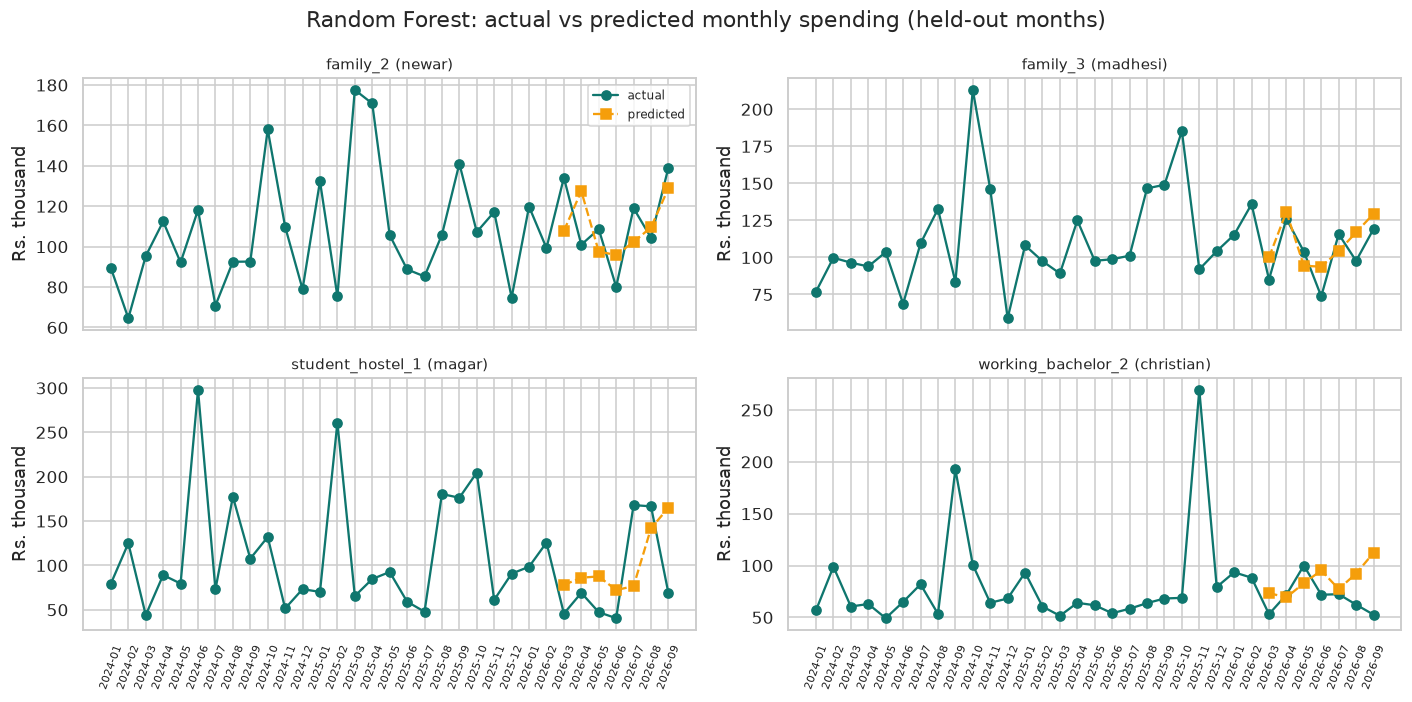

In [20]:
# Refit on every month available and keep it for the app; the fold-2 predictions are shown below.
tr, te = split(FOLDS[1])
fold_model = clone(REGRESSORS[best_forecast_name]).fit(tr[FEATURES], tr[TARGET])
test = te.copy()
test["predicted"] = fold_model.predict(test[FEATURES])

best_forecast = clone(REGRESSORS[best_forecast_name]).fit(frame[FEATURES], frame[TARGET])

sample_households = ["family_2", "family_3", "student_hostel_1", "working_bachelor_2"]
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), sharex=True)
for ax, household in zip(axes.ravel(), sample_households):
    history = frame[frame.household == household]
    ax.plot(history.period.astype(str), history.total_npr / 1000, marker="o", color="#0f766e", label="actual")
    subset = test[test.household == household]
    ax.plot(subset.period.astype(str), subset.predicted / 1000, marker="s", linestyle="--",
            color="#f59e0b", label="predicted")
    profile = households.set_index("household").loc[household, "celebration_profile"]
    ax.set_title(f"{household} ({profile})", fontsize=10)
    ax.set_ylabel("Rs. thousand")
    ax.tick_params(axis="x", rotation=70, labelsize=7)
axes[0][0].legend(fontsize=8)
plt.suptitle(f"{best_forecast_name}: actual vs predicted monthly spending (held-out months)")
plt.tight_layout()
plt.show()

In [21]:
by_group = (test.assign(abs_error=(test.total_npr - test.predicted).abs(),
                        pct_error=((test.total_npr - test.predicted).abs() / test.total_npr))
            .groupby("group_type")
            .agg(months=("total_npr", "size"), mean_actual=("total_npr", "mean"),
                 MAE=("abs_error", "mean"), MAPE=("pct_error", "mean")))
by_group.round({"mean_actual": 0, "MAE": 0, "MAPE": 3})

,months,mean_actual,MAE,MAPE
group_type,,,,
college,21,61762.0,16687.0,0.371
family,21,101508.0,25516.0,0.278
roommates,42,80664.0,28705.0,0.423
trip,21,22869.0,14293.0,1.001


In absolute rupees the error tracks the size of each group's spending. In relative terms the family
series, dominated by recurring bills, is predicted most closely, and trip groups are by far the
hardest: their spending arrives in bursts, and a group can record almost nothing for two months and
then book a hotel, a bus and a paragliding flight in one weekend. That is why the app shows the
forecast as a range with the reasons behind it, worded as what *might* happen, not as one confident
number.

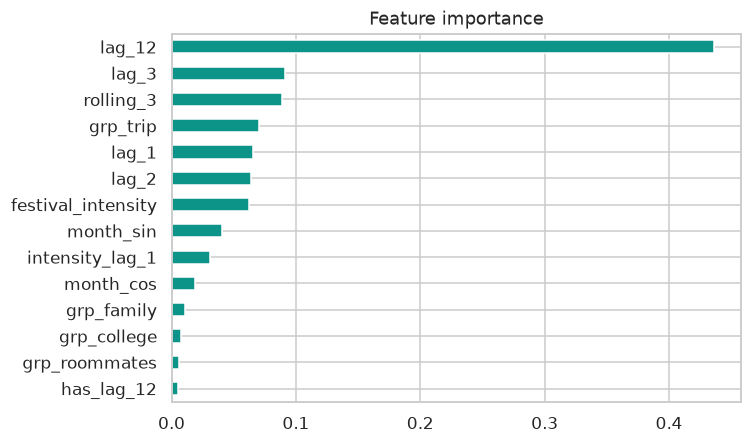

lag_12                0.4364
lag_3                 0.0914
rolling_3             0.0892
grp_trip              0.0704
lag_1                 0.0659
lag_2                 0.0642
festival_intensity    0.0622
month_sin             0.0408
intensity_lag_1       0.0308
month_cos             0.0188
grp_family            0.0112
grp_college           0.0075
grp_roommates         0.0059
has_lag_12            0.0053
dtype: float64

In [22]:
if hasattr(best_forecast, "feature_importances_"):
    importance = pd.Series(best_forecast.feature_importances_, index=FEATURES)
    title = "Feature importance"
else:
    importance = pd.Series(np.abs(best_forecast.coef_), index=FEATURES)
    title = "Absolute coefficient size"

importance.sort_values().plot(kind="barh", figsize=(7, 4.2), color="#0d9488")
plt.title(title)
plt.tight_layout()
plt.show()
importance.sort_values(ascending=False).round(4)

In [23]:
intensity_map = national_intensity_by_month(calendar)
details_map = festival_details_by_month(calendar)

joblib.dump(
    {"model": best_forecast, "features": FEATURES, "model_name": best_forecast_name,
     "feature_set": best_row.features, "target": TARGET, "serving_clamp": SERVING_CLAMP,
     "group_columns": GROUP_COLS, "festival_intensity": intensity_map, "festivals": details_map,
     "calendar_range": [min(intensity_map), max(intensity_map)],
     "sklearn_version": __import__("sklearn").__version__},
    MODELS / "spend_forecast.joblib",
)
print("saved", (MODELS / "spend_forecast.joblib").name,
      "| calendar months covered:", min(details_map), "to", max(details_map))

saved spend_forecast.joblib | calendar months covered: 2023-09 to 2027-12


## 7. Metrics written for the application and the report

In [24]:
metrics = {
    "dataset": {
        "expenses": int(len(expenses)),
        "unique_descriptions": int(expenses.description.nunique()),
        "households": int(expenses.household.nunique()),
        "months": int(monthly.period.nunique()),
        "date_range": [str(expenses.date.min().date()), str(expenses.date.max().date())],
        "categories": labels,
        "festival_calendar_rows": len(calendar),
        "festival_share_of_expenses": float(expenses.festival.ne("").mean()),
        "festival_share_of_money": float(expenses.loc[expenses.festival.ne(""), "amount_npr"].sum()
                                         / expenses.amount_npr.sum()),
    },
    "classifier": {
        "selected_model": best_name,
        "uses_amount_feature": bool(use_amount),
        "test_accuracy": float(accuracy_score(y_test, final_pred)),
        "test_macro_f1": float(f1_score(y_test, final_pred, average="macro")),
        "cross_validation": results.to_dict(orient="records"),
        "per_class_f1": {
            label: float(score) for label, score in zip(
                labels, f1_score(y_test, final_pred, average=None, labels=labels))
        },
    },
    "forecaster": {
        "selected_model": best_forecast_name,
        "feature_set": best_row.features,
        "target": TARGET,
        "folds": FOLDS,
        "serving_clamp": list(SERVING_CLAMP),
        "by_group_type": by_group.round(4).reset_index().to_dict(orient="records"),
        "features": FEATURES,
        "comparison": forecast_results.to_dict(orient="records"),
    },
}

with (MODELS / "metrics.json").open("w", encoding="utf-8") as handle:
    json.dump(metrics, handle, indent=2)

print(json.dumps({k: v for k, v in metrics["classifier"].items()
                  if k not in ("cross_validation", "per_class_f1")}, indent=2))
print(json.dumps(metrics["dataset"], indent=2))

{
  "selected_model": "Logistic Regression",
  "uses_amount_feature": true,
  "test_accuracy": 0.9723655121591747,
  "test_macro_f1": 0.960681004941072
}
{
  "expenses": 12822,
  "unique_descriptions": 5342,
  "households": 15,
  "months": 36,
  "date_range": [
    "2023-10-01",
    "2026-09-30"
  ],
  "categories": [
    "education",
    "entertainment",
    "food",
    "hotel",
    "other",
    "rent",
    "shopping",
    "transport",
    "utilities"
  ],
  "festival_calendar_rows": 118,
  "festival_share_of_expenses": 0.1417875526438933,
  "festival_share_of_money": 0.15519103751502006
}


## 8. Conclusion and limitations

**Results.** The category classifier reaches the accuracy and macro F1 reported in section 4 on a
grouped, held-out 20% test set, far above the majority-class baseline of about 31% (always
predicting *food*). Because the split is grouped by wording, that score is earned on descriptions
the model has never seen, and the remaining errors sit almost entirely on the deliberately ambiguous
entries, where the text alone does not determine the category.

The forecaster beats both naive baselines on mean absolute error across two held-out windows, and
the festival calendar together with the same-month-last-year feature beats the old calendar-blind
October/November rule. Its relative error nonetheless stays high: it is a guide to the scale of next
month's spending, presented in the app with its range and its reasons, not a precise prediction.

**Limitations, stated plainly.**

1. The dataset is synthesised from published prices, not collected from real users. Prices and
   seasonality are realistic; individual behaviour is modelled, not observed.
2. Thirty-six months across fifteen households is a small basis for forecasting. The model captures
   the festival calendar, annual repeats and the recent trend, but not one-off events.
3. The number of purchases each festival causes is a modelling assumption ranked by festival size.
   The dates and the prices are sourced; the volumes are not measured.
4. Descriptions are Romanised Nepali and English. Text written in Devanagari would need either
   transliteration or a retrained vectoriser.
5. The classifier's confidence is calibrated on this dataset only. Once real users correct
   suggestions in the app, those corrections become the natural training set for a better model, and
   retraining on them is the single most valuable next step.

**How the models reach the application.** Both artefacts are written to `ml/models/`. The Django
service loads them lazily with joblib and falls back to keyword matching if the files are absent, so
the application still runs on a machine where this notebook has never been executed.